LightCNN for image classification

Running on: cuda


100%|██████████| 2.64G/2.64G [06:22<00:00, 6.90MB/s]


Train: 5000 | Val: 8000 | Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Params: 1,240,570
Epoch  1/40 | Train loss 2.2402 acc 0.1614 | Val loss 1.7839 acc 0.3231 | LR 0.000976 | 24.9s
Epoch  2/40 | Train loss 2.0480 acc 0.1976 | Val loss 1.6479 acc 0.3815 | LR 0.000905 | 18.6s
Epoch  3/40 | Train loss 1.9512 acc 0.2026 | Val loss 1.5583 acc 0.4308 | LR 0.000796 | 19.8s
Epoch  4/40 | Train loss 1.9040 acc 0.2236 | Val loss 1.5824 acc 0.4255 | LR 0.000658 | 18.7s
Epoch  5/40 | Train loss 1.8619 acc 0.2220 | Val loss 1.4702 acc 0.4556 | LR 0.000505 | 19.6s
Epoch  6/40 | Train loss 1.7948 acc 0.2718 | Val loss 1.3690 acc 0.4901 | LR 0.000352 | 19.3s
Epoch  7/40 | Train loss 1.7590 acc 0.3162 | Val loss 1.3216 acc 0.5205 | LR 0.000214 | 19.4s
Epoch  8/40 | Train loss 1.7161 acc 0.2858 | Val loss 1.2738 acc 0.5397 | LR 0.000105 | 19.7s
Epoch  9/40 | Train loss 1.7236 acc 0.2910 | Val loss 1.2451 acc 0.5534 | LR 0.000034 | 19.4s
Epoch 10/40 | T

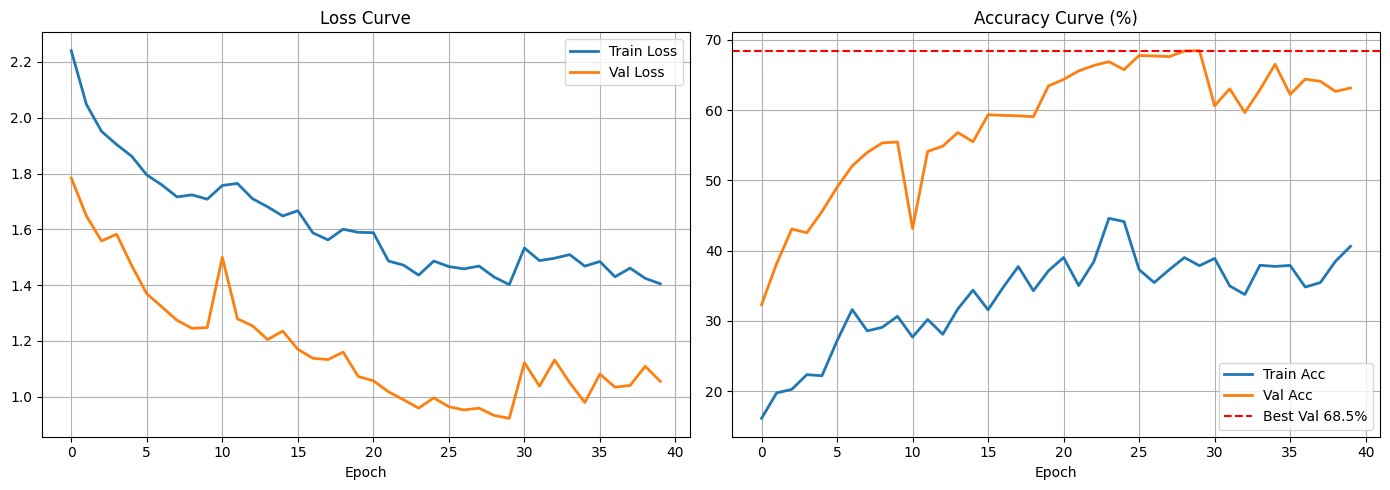

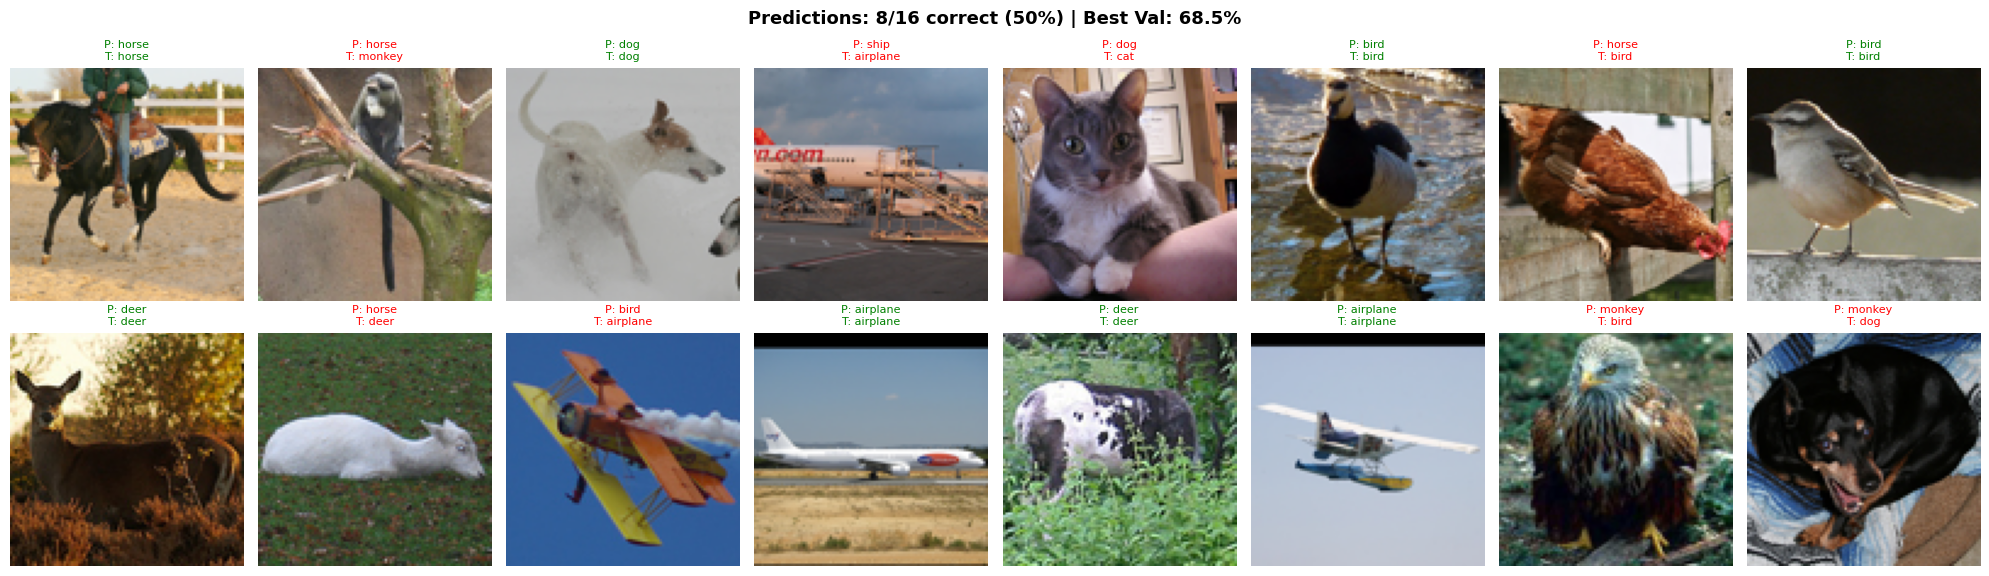


📊 Per-Class Accuracy:
-----------------------------------
  airplane    :  85.0%  █████████████████
  bird        :  67.1%  █████████████
  car         :  84.5%  ████████████████
  cat         :  44.8%  ████████
  deer        :  60.8%  ████████████
  dog         :  38.6%  ███████
  horse       :  75.6%  ███████████████
  monkey      :  71.1%  ██████████████
  ship        :  83.1%  ████████████████
  truck       :  73.9%  ██████████████
-----------------------------------
  Overall     :  68.5%


In [ ]:
# ============================================================
# OPTIMIZED LightCNN + Residual Attention on STL10 (96x96)
# Google Colab Compatible | Target: 70%+ accuracy
# Key upgrades:
#   1. Deeper architecture (4 stages instead of 3)
#   2. CBAM-style attention (Channel + Spatial combined)
#   3. Cosine Annealing LR scheduler with warm restarts
#   4. Label Smoothing loss
#   5. Mixup data augmentation
#   6. Stronger augmentations (AutoAugment / RandAugment)
#   7. Weight decay + gradient clipping
#   8. Bottleneck residual blocks for efficiency
#   9. Dropout before classifier
#  10. Full dataset usage (5000 train, 8000 test)
# ============================================================

# ── Install ──────────────────────────────────────────────────
# !pip install -q torch torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
import time

# ─────────────────────────────────────────────
# 1. CONFIG
# ─────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 64
EPOCHS      = 40          # More epochs → better convergence
LR          = 1e-3
WEIGHT_DECAY = 5e-4       # L2 regularisation
MIXUP_ALPHA = 0.2         # Mixup interpolation strength (0 = off)
LABEL_SMOOTH = 0.1        # Label smoothing ε
SEED        = 42
NUM_CLASSES = 10

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True  # speeds up training on fixed-size inputs

print(f"Running on: {DEVICE}")

# ─────────────────────────────────────────────
# 2. DATASET  (full STL10 — no subset truncation)
# ─────────────────────────────────────────────
STL_MEAN = (0.4467, 0.4398, 0.4066)
STL_STD  = (0.2603, 0.2566, 0.2713)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=12),          # more aggressive crop
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),    # colour aug
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(STL_MEAN, STL_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))  # Cutout-style
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL_MEAN, STL_STD)
])

train_ds = datasets.STL10(root='./data', split="train", download=True, transform=transform_train)
val_ds   = datasets.STL10(root='./data', split="test",  download=True, transform=transform_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

classes = train_ds.classes
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Classes: {classes}")

# ─────────────────────────────────────────────
# 3. MODEL COMPONENTS
# ─────────────────────────────────────────────

# ── 3a. Bottleneck Residual Block ─────────────
class BottleneckBlock(nn.Module):
    """
    1×1 → 3×3 → 1×1 bottleneck.
    Reduces params vs plain ResBlock while going deeper.
    expansion=4: internal channels = planes * 4
    """
    expansion = 2

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        mid = planes
        out = planes * self.expansion

        self.conv1 = nn.Conv2d(in_planes, mid, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(mid)
        self.conv2 = nn.Conv2d(mid, mid, 3, stride, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(mid)
        self.conv3 = nn.Conv2d(mid, out, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(out)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out, 1, stride, bias=False),
                nn.BatchNorm2d(out)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = F.relu(self.bn2(self.conv2(out)), inplace=True)
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        return F.relu(out, inplace=True)


# ── 3b. CBAM Channel Attention ────────────────
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        return x * torch.sigmoid(avg_out + max_out)


# ── 3c. CBAM Spatial Attention ────────────────
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        pad = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=pad, bias=False)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


# ── 3d. Full CBAM (Channel + Spatial) ─────────
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))


# ── 3e. Residual-Attention Block ──────────────
class ResAttBlock(nn.Module):
    """Bottleneck + CBAM attention + residual connection."""
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.block = BottleneckBlock(in_planes, planes, stride)
        out = planes * BottleneckBlock.expansion
        self.cbam = CBAM(out)
        # project input to match output for residual
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out, 1, stride, bias=False),
                nn.BatchNorm2d(out)
            )

    def forward(self, x):
        feat = self.block(x)
        feat = self.cbam(feat)
        return F.relu(feat + self.shortcut(x), inplace=True)


# ── 3f. Full LightCNN-AttNet ──────────────────
class LightCNNAtt(nn.Module):
    """
    4-stage network:
      Stem  : 3 → 32 (stride-1 conv)
      Stage1: 32 → 64  (stride-1, attention)
      Stage2: 64 → 128 (stride-2, attention)
      Stage3: 128→ 256 (stride-2, attention)
      Stage4: 256→ 256 (stride-2, attention)
      Global Average Pool → Dropout → FC(10)
    """
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()

        # Stem: 96×96 → 96×96, 32 ch
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 96→48
        )

        # Stage 1: 48×48
        self.stage1 = self._make_stage(32, 32, stride=1)   # out: 64ch
        # Stage 2: 48→24
        self.stage2 = self._make_stage(64, 64, stride=2)   # out: 128ch
        # Stage 3: 24→12
        self.stage3 = self._make_stage(128, 128, stride=2) # out: 256ch
        # Stage 4: 12→6
        self.stage4 = self._make_stage(256, 128, stride=2) # out: 256ch

        self.pool    = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(256, num_classes)

        # Weight initialisation
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    @staticmethod
    def _make_stage(in_planes, planes, stride):
        return nn.Sequential(
            ResAttBlock(in_planes, planes, stride=stride),
            ResAttBlock(planes * BottleneckBlock.expansion,
                        planes * BottleneckBlock.expansion // BottleneckBlock.expansion,
                        stride=1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


# ─────────────────────────────────────────────
# 4. LOSS:  Label Smoothing Cross-Entropy
# ─────────────────────────────────────────────
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1, num_classes=10):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, pred, target):
        log_prob = F.log_softmax(pred, dim=1)
        # one-hot smoothed target
        with torch.no_grad():
            smooth_target = torch.full_like(log_prob,
                                            self.smoothing / (self.num_classes - 1))
            smooth_target.scatter_(1, target.unsqueeze(1),
                                   1.0 - self.smoothing)
        return -(smooth_target * log_prob).sum(dim=1).mean()


# ─────────────────────────────────────────────
# 5. MIXUP
# ─────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam


def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ─────────────────────────────────────────────
# 6. BUILD MODEL
# ─────────────────────────────────────────────
model     = LightCNNAtt(num_classes=NUM_CLASSES, dropout=0.4).to(DEVICE)
criterion = LabelSmoothingCE(smoothing=LABEL_SMOOTH, num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5
)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Params: {count_params(model):,}")


# ─────────────────────────────────────────────
# 7. EVALUATION
# ─────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    plain_ce = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            out   = model(images)
            loss_sum += plain_ce(out, labels).item() * images.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total


# ─────────────────────────────────────────────
# 8. TRAINING LOOP
# ─────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

best_val_acc = 0.0
best_state   = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # ── Mixup ──
        mx_images, y_a, y_b, lam = mixup_data(images, labels, MIXUP_ALPHA)

        optimizer.zero_grad()
        outputs = model(mx_images)
        loss    = mixup_loss(criterion, outputs, y_a, y_b, lam)
        loss.backward()

        # Gradient clipping → stable training
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_acc  = correct / total
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:>2}/{EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"LR {lr_now:.6f} | {elapsed:.1f}s")

print(f"\n✅ Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

# Restore best weights
model.load_state_dict(best_state)
model.to(DEVICE)


# ─────────────────────────────────────────────
# 9. TRAINING CURVES
# ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(history["val_loss"],   label="Val Loss",   linewidth=2)
ax1.set_title("Loss Curve"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)

ax2.plot([a*100 for a in history["train_acc"]], label="Train Acc", linewidth=2)
ax2.plot([a*100 for a in history["val_acc"]],   label="Val Acc",   linewidth=2)
ax2.axhline(best_val_acc*100, color='r', linestyle='--',
            label=f"Best Val {best_val_acc*100:.1f}%")
ax2.set_title("Accuracy Curve (%)"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# 10. PREDICTION VISUALISATION  (16 samples)
# ─────────────────────────────────────────────
def denormalise(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array(STL_MEAN)
    std  = np.array(STL_STD)
    return np.clip(std * img + mean, 0, 1)

model.eval()
sample_imgs, sample_lbls = next(iter(val_loader))
sample_imgs = sample_imgs[:16].to(DEVICE)
sample_lbls = sample_lbls[:16]

with torch.no_grad():
    preds = model(sample_imgs).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
correct_count = 0
for i, ax in enumerate(axes.flat):
    img = denormalise(sample_imgs[i])
    ax.imshow(img)
    pred_lbl = classes[preds[i]]
    true_lbl = classes[sample_lbls[i]]
    ok = pred_lbl == true_lbl
    if ok:
        correct_count += 1
    ax.set_title(f"P: {pred_lbl}\nT: {true_lbl}",
                 color="green" if ok else "red", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Predictions: {correct_count}/16 correct "
             f"({correct_count/16*100:.0f}%) | Best Val: {best_val_acc*100:.1f}%",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# 11. PER-CLASS ACCURACY
# ─────────────────────────────────────────────
model.eval()
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds_all = model(images).argmax(1)
        for p, t in zip(preds_all, labels):
            class_total[t]   += 1
            class_correct[t] += int(p == t)

print("\n📊 Per-Class Accuracy:")
print("-" * 35)
for i, cls in enumerate(classes):
    acc = class_correct[i] / max(class_total[i], 1) * 100
    bar = "█" * int(acc / 5)
    print(f"  {cls:12s}: {acc:5.1f}%  {bar}")
print("-" * 35)
overall = sum(class_correct) / sum(class_total) * 100
print(f"  {'Overall':12s}: {overall:5.1f}%")